# Notebook 01 — EDA v2: Phân tích 50 bài MBPP mở rộng
**Nhóm 67 | Tuần 3 | Ngôn ngữ lập trình Python**

Thống kê mô tả và phân tích phân bổ chủ đề, độ dài mô tả, độ dài code mẫu trên 50 bài MBPP.

# B1 - Kết nối Google Drive


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


# B2 - Import thư viện và load dữ liệu


In [ ]:
import os
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Auto-resolve relative path to Project directory
BASE = Path("/content/drive/MyDrive/Project")

DATA_FILE = BASE / 'data' / 'processed' / 'hidden_v2.json'
print(f"Loading data from relative path: {DATA_FILE}")

with open(DATA_FILE, encoding='utf-8') as f:
    problems = json.load(f)

print(f"✓ Doc xong: {len(problems)} bai toan")

Loading data from relative path: /content/drive/MyDrive/Project/data/processed/hidden_v2.json
✓ Doc xong: 50 bai toan


# B3 - Tạo DataFrame và thống kê mô tả


In [ ]:
df = pd.DataFrame(problems)
df['num_public_tests'] = df['public_tests'].apply(len)
df['num_hidden_tests'] = df['hidden_tests'].apply(len)
df['desc_word_count'] = df['text'].apply(lambda x: len(x.split()))
df['code_line_count'] = df['code'].apply(lambda x: len(x.strip().split('\n')))

print("=============================================================")
print("  BANG THONG KE MO TA BO DU LIEU MBPP_50")
print("=============================================================")
print(f"  Tong so bai toan               : {len(df)}")
print(f"  Phan bo chu de (Topic distribution):")
for topic, count in df['topic'].value_counts().items():
    print(f"    - {topic:<15} : {count} bai")
print(f"  So public tests trung binh/bai : {df['num_public_tests'].mean():.1f} (min={df['num_public_tests'].min()}, max={df['num_public_tests'].max()})")
print(f"  So hidden tests trung binh/bai : {df['num_hidden_tests'].mean():.1f} (min={df['num_hidden_tests'].min()}, max={df['num_hidden_tests'].max()})")
print(f"  Do dai mo ta trung binh (tu)  : {df['desc_word_count'].mean():.1f}")
print(f"  Do dai code mau trung binh (dong): {df['code_line_count'].mean():.1f}")
print("=============================================================")

  BANG THONG KE MO TA BO DU LIEU MBPP_50
  Tong so bai toan               : 50
  Phan bo chu de (Topic distribution):
    - list            : 20 bai
    - string          : 16 bai
    - math            : 14 bai
  So public tests trung binh/bai : 3.0 (min=3, max=3)
  So hidden tests trung binh/bai : 8.0 (min=6, max=10)
  Do dai mo ta trung binh (tu)  : 14.4
  Do dai code mau trung binh (dong): 2.8


# B4 - Vẽ biểu đồ phân bố topic, độ dài mô tả, số test case

/tmp/ipykernel_4370/3172274579.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(data=df, x='topic', palette='viridis')


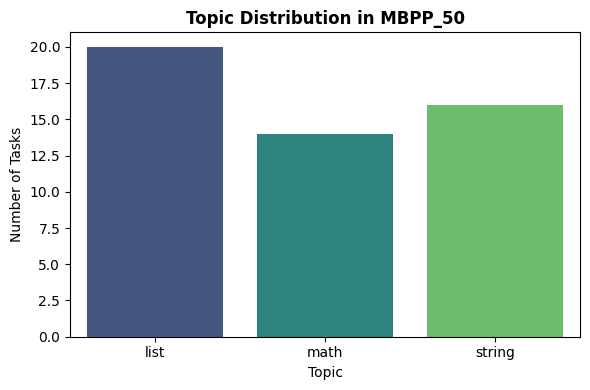

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=df, x='topic', palette='viridis')
plt.title("Topic Distribution in MBPP_50", fontsize=12, fontweight='bold')
plt.xlabel("Topic")
plt.ylabel("Number of Tasks")
plt.tight_layout()
os.makedirs(BASE / 'results', exist_ok=True)
plt.savefig(BASE / 'results' / 'topic_distribution.png', dpi=300)
plt.show()